In [1]:
from pcovr import get_triple_row_plot, plot_pcovr_lips

In [4]:
import numpy as np

mace_feats_1st = np.load("../../data/features/cumulants/1_cumulant_mace.npy")
pet_feats_1st = np.load("../../data/features/cumulants/1_cumulant_pet.npy")
dpa_feats_1st = np.load("../../data/features/cumulants/1_cumulant_dpa.npy")
uma_feats_1st = np.load("../../data/features/cumulants/1_cumulant_uma.npy")

In [5]:
import numpy as np

mace_feats_8st = np.load("../../data/features/cumulants/8_cumulant_mace.npy")
pet_feats_8st = np.load("../../data/features/cumulants/8_cumulant_pet.npy")
dpa_feats_8st = np.load("../../data/features/cumulants/8_cumulant_dpa.npy")
uma_feats_8st = np.load("../../data/features/cumulants/8_cumulant_uma.npy")

In [6]:
from sklearn.ensemble import IsolationForest

contamination_rate = 0.0001 

iso_forest = IsolationForest(
    contamination=contamination_rate, 
    random_state=42
)

outlier_predictions = iso_forest.fit_predict(mace_feats_1st)

outlier_indices = np.where(outlier_predictions == -1)[0]
inlier_indices = np.where(outlier_predictions == 1)[0]

print(f"Total structures: {len(mace_feats_1st)}")
print(f"Identified {len(outlier_indices)} outliers (contamination={contamination_rate*100}%)")
print(f"Outlier indices: {outlier_indices[:10]}...")

Total structures: 9461
Identified 1 outliers (contamination=0.01%)
Outlier indices: [7600]...


In [19]:
from sklearn.ensemble import IsolationForest

contamination_rate = 0.0001 

iso_forest = IsolationForest(
    contamination=contamination_rate, 
    random_state=42
)

outlier_predictions = iso_forest.fit_predict(mace_feats_8st)

outlier_indices_8st = np.where(outlier_predictions == -1)[0]
inlier_indices_8st = np.where(outlier_predictions == 1)[0]

In [8]:
import ase.io
import numpy as np
from featomic import AtomicComposition
from sklearn.linear_model import RidgeCV

structures_not_processed = ase.io.read("../data/xyz/mad-test-consistent-not-processed.xyz", ":")
structures = ase.io.read("../data/xyz/mad-test-consistent.xyz", ":")
gt_energy = np.array([atoms.get_potential_energy() for atoms in structures_not_processed])
natoms = np.array([len(f) for f in structures])

calculator = AtomicComposition(**{"per_system": True})
rho0 = calculator.compute(structures)

comp_feats = rho0.keys_to_properties(["center_type"]).block(0).values

ridge_model = RidgeCV(alphas=np.geomspace(1e-8, 1e2, 20))
ridge_model.fit(comp_feats, gt_energy)

gt_atom_baseline = ridge_model.predict(comp_feats)

gt_cohesive_total = gt_energy - gt_atom_baseline
gt_cohesive_peratom = gt_cohesive_total / natoms

In [14]:
from skmatter.decomposition import PCovR
from skmatter.preprocessing import StandardFlexibleScaler


def get_pcovr_feats(features, energies, n_components=2, mixing=0.5):
    sf_feats = StandardFlexibleScaler().fit_transform(features)
    sf_energy = StandardFlexibleScaler().fit_transform(energies.reshape(-1, 1))

    pcovr = PCovR(n_components=n_components, mixing=mixing)
    pcovr.fit(sf_feats, sf_energy)

    print(f"PCovR Explained Variance Ratio: {pcovr.explained_variance_ratio_}")

    return pcovr.transform(sf_feats)

def fit_pcovr_on_full_data(full_features, full_energies, n_components=2, mixing=0.5):
    sf_energy_full = StandardFlexibleScaler().fit_transform(full_energies.reshape(-1, 1))
    sf_feats_full = StandardFlexibleScaler().fit_transform(full_features)
    
    pcovr = PCovR(n_components=n_components, mixing=mixing)
    pcovr.fit(sf_feats_full, sf_energy_full)
    
    return pcovr, sf_feats_full, sf_energy_full


def transform_pcovr_on_subset(pcovr_model, scaled_subset_features):
    return pcovr_model.transform(scaled_subset_features)


In [ ]:
gt_cohesive_peratom_filtered = gt_cohesive_peratom[inlier_indices]

mace_feats_filtered = mace_feats_1st[inlier_indices]
uma_feats_filtered = uma_feats_1st[inlier_indices]
pet_feats_filtered = pet_feats_1st[inlier_indices]
dpa_feats_filtered = dpa_feats_1st[inlier_indices]

pcovr_model_mace, scaled_feats_full, scaled_energy_full = fit_pcovr_on_full_data(
    mace_feats_1st, 
    gt_cohesive_peratom, 
    mixing=0.5
)

feature_scaler_full = StandardFlexibleScaler().fit(mace_feats_1st)
scaled_mace_feats_inliers = feature_scaler_full.transform(mace_feats_filtered)

mace_pcovr_05_inliers = transform_pcovr_on_subset(
    pcovr_model_mace, 
    scaled_mace_feats_inliers
)

uma_pcovr_05 = get_pcovr_feats(uma_feats_filtered, gt_cohesive_peratom_filtered, mixing=0.5)
pet_pcovr_05 = get_pcovr_feats(pet_feats_filtered, gt_cohesive_peratom_filtered, mixing=0.5)
dpa_pcovr_05 = get_pcovr_feats(dpa_feats_filtered, gt_cohesive_peratom_filtered, mixing=0.5)

datasets_1 = [
    (mace_pcovr_05_inliers, gt_cohesive_peratom_filtered, "MACE"), 
    (pet_pcovr_05, gt_cohesive_peratom_filtered, "PET-MAD"),
    (dpa_pcovr_05, gt_cohesive_peratom_filtered, "DPA"),
    (uma_pcovr_05, gt_cohesive_peratom_filtered, "UMA"),
]

PCovR Explained Variance Ratio: [0.76077178 0.23922822]
PCovR Explained Variance Ratio: [0.68541014 0.31458986]
PCovR Explained Variance Ratio: [0.56968036 0.43031964]


In [20]:
mace_feats_filtered = mace_feats_8st[inlier_indices_8st]
uma_feats_filtered = uma_feats_8st[inlier_indices_8st]
pet_feats_filtered = pet_feats_8st[inlier_indices_8st]
dpa_feats_filtered = dpa_feats_8st[inlier_indices_8st]

pcovr_model_mace, scaled_feats_full, scaled_energy_full = fit_pcovr_on_full_data(
    mace_feats_8st,
    gt_cohesive_peratom, 
    mixing=0.5
)

feature_scaler_full = StandardFlexibleScaler().fit(mace_feats_8st)
scaled_mace_feats_inliers = feature_scaler_full.transform(mace_feats_filtered)

mace_pcovr_05_inliers = transform_pcovr_on_subset(
    pcovr_model_mace, 
    scaled_mace_feats_inliers
)

uma_pcovr_05 = get_pcovr_feats(uma_feats_filtered, gt_cohesive_peratom_filtered, mixing=0.5)
pet_pcovr_05 = get_pcovr_feats(pet_feats_filtered, gt_cohesive_peratom_filtered, mixing=0.5)
dpa_pcovr_05= get_pcovr_feats(dpa_feats_filtered, gt_cohesive_peratom_filtered, mixing=0.5)

datasets_8 = [
    (mace_pcovr_05_inliers, gt_cohesive_peratom_filtered, "MACE"), 
    (pet_pcovr_05, gt_cohesive_peratom_filtered, "PET-MAD"),
    (dpa_pcovr_05, gt_cohesive_peratom_filtered, "DPA"),
    (uma_pcovr_05, gt_cohesive_peratom_filtered, "UMA"),
]

PCovR Explained Variance Ratio: [0.75989888 0.24010112]
PCovR Explained Variance Ratio: [0.8711813 0.1288187]
PCovR Explained Variance Ratio: [0.78420876 0.21579124]


In [17]:
labels = [atoms.info.get("subset") for atoms in structures]
labels_filt = np.array(labels)[inlier_indices]

/Users/sofiia/cosmo/carto-speedrun/universal_feature_space_comparison/ploting/pcovr.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.98])


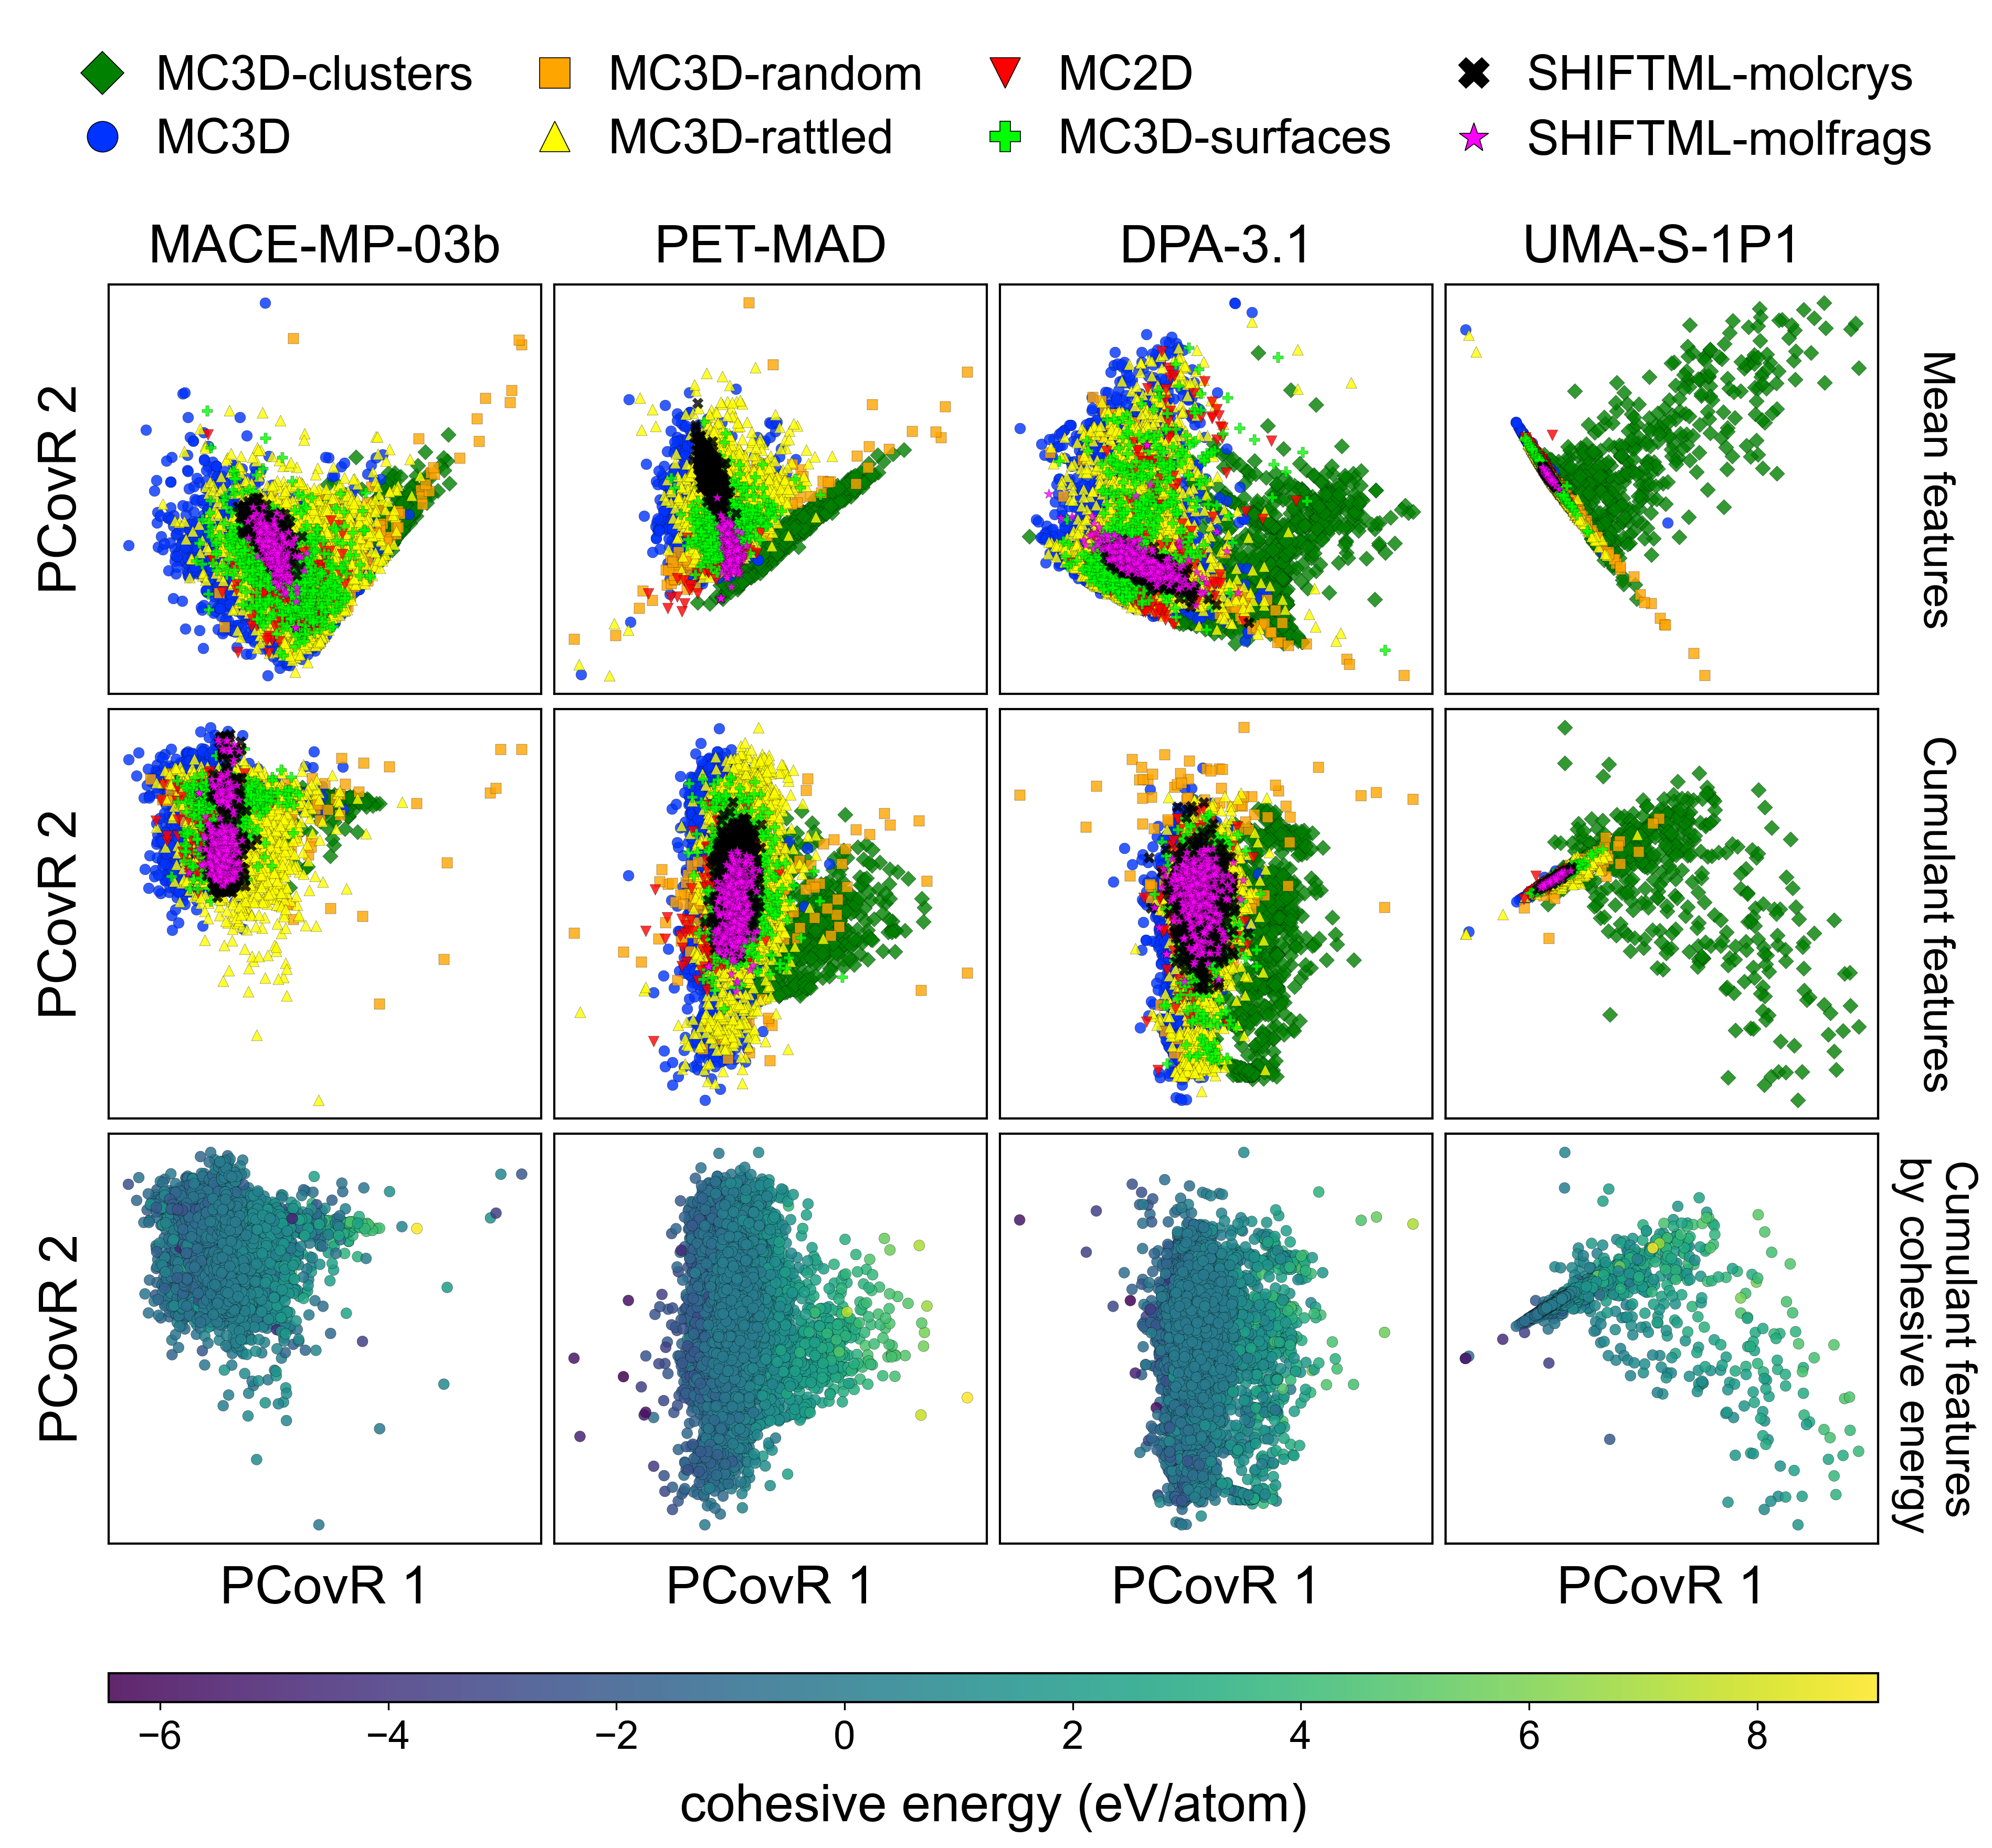

In [22]:
get_triple_row_plot(datasets_1, datasets_8, labels_filt, cbar_title="cohesive energy (eV/atom)", save_path='../results/figures/cumulants/pcovr.pdf')

## LiPS

In [4]:
import numpy as np
import ase.io
from featomic import AtomicComposition
from sklearn.linear_model import RidgeCV
from skmatter.preprocessing import StandardFlexibleScaler
from skmatter.decomposition import PCovR

structures_not_processed = ase.io.read("../../data/raw/mad-test-consistent-not-processed.xyz", ":")
structures = ase.io.read("../../data/raw/mad-test-consistent.xyz", ":")
gt_energy = np.array([atoms.get_potential_energy() for atoms in structures_not_processed])
natoms = np.array([len(f) for f in structures])

calculator = AtomicComposition(**{"per_system": True})
rho0 = calculator.compute(structures)

comp_feats = rho0.keys_to_properties(["center_type"]).block(0).values

ridge_model = RidgeCV(alphas=np.geomspace(1e-8, 1e2, 20))
ridge_model.fit(comp_feats, gt_energy)

gt_atom_baseline = ridge_model.predict(comp_feats)

gt_cohesive_total = gt_energy - gt_atom_baseline
gt_cohesive_peratom = gt_cohesive_total / natoms


structures_lips = ase.io.read("../../data/raw/lips/LPS.extxyz", ":")
gt_energy_lips = np.array([atoms.get_potential_energy() for atoms in structures_lips])
natoms_lips = np.array([len(f) for f in structures_lips])

calculator = AtomicComposition(**{"per_system": True})
rho0 = calculator.compute(structures_lips)

comp_feats_lips = rho0.keys_to_properties(["center_type"]).block(0).values

ridge_model_lips = RidgeCV(alphas=np.geomspace(1e-8, 1e2, 20))
ridge_model_lips.fit(comp_feats_lips, gt_energy_lips)

gt_atom_baseline_lips = ridge_model_lips.predict(comp_feats_lips)

gt_cohesive_total_lips = gt_energy_lips - gt_atom_baseline_lips
gt_cohesive_peratom_lips = gt_cohesive_total_lips / natoms_lips

labels_lips = [atoms.info.get("subset") for atoms in structures_lips]

# --- MAD ---
petmad_mad = np.load("../data/features/fine-tuning/mad/pet-mad_mad.npy")
head_ft_mad = np.load("../data/features/fine-tuning/mad/hf_mad.npy")
ff_mad = np.load("../data/features/fine-tuning/mad/ff_mad.npy")
tl_mad = np.load("../data/features/fine-tuning/mad/ftl_mad.npy")
tl_head_only_mad = np.load("../data/features/fine-tuning/mad/htl_mad.npy")

# --- LIPS ---
petmad_lips = np.load("../data/features/fine-tuning/pet-mad_lips.npy")
head_ft_lips = np.load("../data/features/fine-tuning/hf_lips.npy")
ff_lips = np.load("../data/features/fine-tuning/ff_lips.npy")
tl_lips = np.load("../data/features/fine-tuning/ftl_lips.npy")
tl_head_only_lips = np.load("../data/features/fine-tuning/htl_lips.npy")

def get_struct_feats(atom_feats, dataset, combined=False):
    n_atoms = [len(atoms) for atoms in dataset]
    features = []
    start = 0
    for n in n_atoms:
        block = atom_feats[start:start+n]
        mean_feat = block.mean(axis=0)
        
        if combined and n > 1:
            std_feat = block.std(axis=0)
            features.append(np.concatenate([mean_feat, std_feat]))
        else:
            features.append(mean_feat)
        start += n

    return np.vstack(features)

petmad_mad_str = get_struct_feats(petmad_mad, structures, True)
head_ft_mad_str = get_struct_feats(head_ft_mad, structures, True)
ff_mad_str = get_struct_feats(ff_mad, structures, True)
tl_mad_str = get_struct_feats(tl_mad, structures, True)
tl_head_only_mad_str = get_struct_feats(tl_head_only_mad, structures, True)

petmad_lips_str = get_struct_feats(petmad_lips, structures_lips, True)
head_ft_lips_str = get_struct_feats(head_ft_lips, structures_lips, True)
ff_lips_str = get_struct_feats(ff_lips, structures_lips, True)
tl_lips_str = get_struct_feats(tl_lips, structures_lips, True)
tl_head_only_lips_str = get_struct_feats(tl_head_only_lips, structures_lips, True)


def fit_pcovr(features, energies, n_components=2, mixing=0.5):
    sf_energy = StandardFlexibleScaler().fit(energies.reshape(-1, 1))
    sf_feats = StandardFlexibleScaler().fit(features)
    
    scaled_energy = sf_energy.transform(energies.reshape(-1, 1))
    scaled_features = sf_feats.transform(features)

    pcovr = PCovR(n_components=n_components, mixing=mixing)
    pcovr.fit(scaled_features, scaled_energy)
    print(f"explained variance ratio (fit): {pcovr.explained_variance_ratio_}")
    
    pcovr_model = {
        'pcovr': pcovr,
        'sf_energy': sf_energy,
        'sf_feats': sf_feats
    }
    return pcovr_model


def transform_pcovr(features, pcovr_model):
    scaled_features = pcovr_model['sf_feats'].transform(features)
    
    pcovr_features = pcovr_model['pcovr'].transform(scaled_features)
    
    return pcovr_features


pcovr_models_mad = {}

print("\nFitting PCovR models on MAD data...")
pcovr_models_mad['petmad'] = fit_pcovr(petmad_mad_str, gt_cohesive_peratom, mixing=0.5)
pcovr_models_mad['head_ft'] = fit_pcovr(head_ft_mad_str, gt_cohesive_peratom, mixing=0.5)
pcovr_models_mad['ff'] = fit_pcovr(ff_mad_str, gt_cohesive_peratom, mixing=0.5)
pcovr_models_mad['tl'] = fit_pcovr(tl_mad_str, gt_cohesive_peratom, mixing=0.5)
pcovr_models_mad['tl_head_only'] = fit_pcovr(tl_head_only_mad_str, gt_cohesive_peratom, mixing=0.5)

print("\nTransforming MAD features...")
petmad_mad_pcovr = transform_pcovr(petmad_mad_str, pcovr_models_mad['petmad'])
head_ft_mad_pcovr = transform_pcovr(head_ft_mad_str, pcovr_models_mad['head_ft'])
ff_mad_pcovr = transform_pcovr(ff_mad_str, pcovr_models_mad['ff'])
tl_mad_pcovr = transform_pcovr(tl_mad_str, pcovr_models_mad['tl'])
tl_head_only_mad_pcovr = transform_pcovr(tl_head_only_mad_str, pcovr_models_mad['tl_head_only'])

print("\nTransforming LIPS features using MAD PCovR models...")
petmad_lips_pcovr_from_mad = transform_pcovr(petmad_lips_str, pcovr_models_mad['petmad'])
head_ft_lips_pcovr_from_mad = transform_pcovr(head_ft_lips_str, pcovr_models_mad['head_ft'])
ff_lips_pcovr_from_mad = transform_pcovr(ff_lips_str, pcovr_models_mad['ff'])
tl_lips_pcovr_from_mad = transform_pcovr(tl_lips_str, pcovr_models_mad['tl'])
tl_head_only_lips_pcovr_from_mad = transform_pcovr(tl_head_only_lips_str, pcovr_models_mad['tl_head_only'])

datasets = [
    (petmad_mad_pcovr, gt_cohesive_peratom, "PET-MAD (MAD)"),
    (ff_mad_pcovr, gt_cohesive_peratom, "FULL FT (MAD)"),
    (head_ft_mad_pcovr, gt_cohesive_peratom, "HEAD FT (MAD)"),
    (tl_mad_pcovr, gt_cohesive_peratom, "TL (MAD)"),
    (tl_head_only_mad_pcovr, gt_cohesive_peratom, "TL HEAD-ONLY (MAD)"),

    (petmad_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "PET-MAD (LIPS from MAD PCovR)"),    
    (ff_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "FULL FT (LIPS from MAD PCovR)"),
    (head_ft_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "HEAD FT (LIPS from MAD PCovR)"),
    (tl_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "TL (LIPS from MAD PCovR)"),
    (tl_head_only_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "TL HEAD-ONLY (LIPS from MAD PCovR)")
]

lips_labels = [atoms.info.get("subset") for atoms in structures_lips]



Fitting PCovR models on MAD data...


/Users/sofiia/cosmo/scikit-matter/src/skmatter/decomposition/_pcov.py:62: UserWarning: This class does not automatically center data, and your data mean is greater than the supplied tolerance.
  warnings.warn(
/opt/miniconda3/envs/course/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.15394e-11): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


explained variance ratio (fit): [0.7155022 0.2844978]


/Users/sofiia/cosmo/scikit-matter/src/skmatter/decomposition/_pcov.py:62: UserWarning: This class does not automatically center data, and your data mean is greater than the supplied tolerance.
  warnings.warn(
/opt/miniconda3/envs/course/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=3.62786e-11): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


explained variance ratio (fit): [0.72128441 0.27871559]


...

explained variance ratio (fit): [0.71745598 0.28254402]


/Users/sofiia/cosmo/scikit-matter/src/skmatter/decomposition/_pcov.py:62: UserWarning: This class does not automatically center data, and your data mean is greater than the supplied tolerance.
  warnings.warn(
/opt/miniconda3/envs/course/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=1.07739e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


explained variance ratio (fit): [0.63331341 0.36668659]


/Users/sofiia/cosmo/scikit-matter/src/skmatter/decomposition/_pcov.py:62: UserWarning: This class does not automatically center data, and your data mean is greater than the supplied tolerance.
  warnings.warn(
/opt/miniconda3/envs/course/lib/python3.11/site-packages/scipy/_lib/_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=1.54828e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


explained variance ratio (fit): [0.62784535 0.37215465]

Transforming MAD features...

Transforming LIPS features using MAD PCovR models...


In [5]:
datasets = [
    (petmad_mad_pcovr, gt_cohesive_peratom, "PET-MAD (MAD)"),
    (ff_mad_pcovr, gt_cohesive_peratom, "FF (MAD)"),
    (head_ft_mad_pcovr, gt_cohesive_peratom, "HF (MAD)"),
    (tl_mad_pcovr, gt_cohesive_peratom, "FTL (MAD)"),
    (tl_head_only_mad_pcovr, gt_cohesive_peratom, "HTL (MAD)"),

    (petmad_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "PET-MAD (LIPS from MAD PCovR)"),    
    (ff_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "FULL FT (LIPS from MAD PCovR)"),
    (head_ft_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "HEAD FT (LIPS from MAD PCovR)"),
    (tl_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "FTL (LIPS from MAD PCovR)"),
    (tl_head_only_lips_pcovr_from_mad, gt_cohesive_peratom_lips, "TL HEAD-ONLY (LIPS from MAD PCovR)")
]


/Users/sofiia/cosmo/carto-speedrun/universal_feature_space_comparison/ploting/pcovr.py:367: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


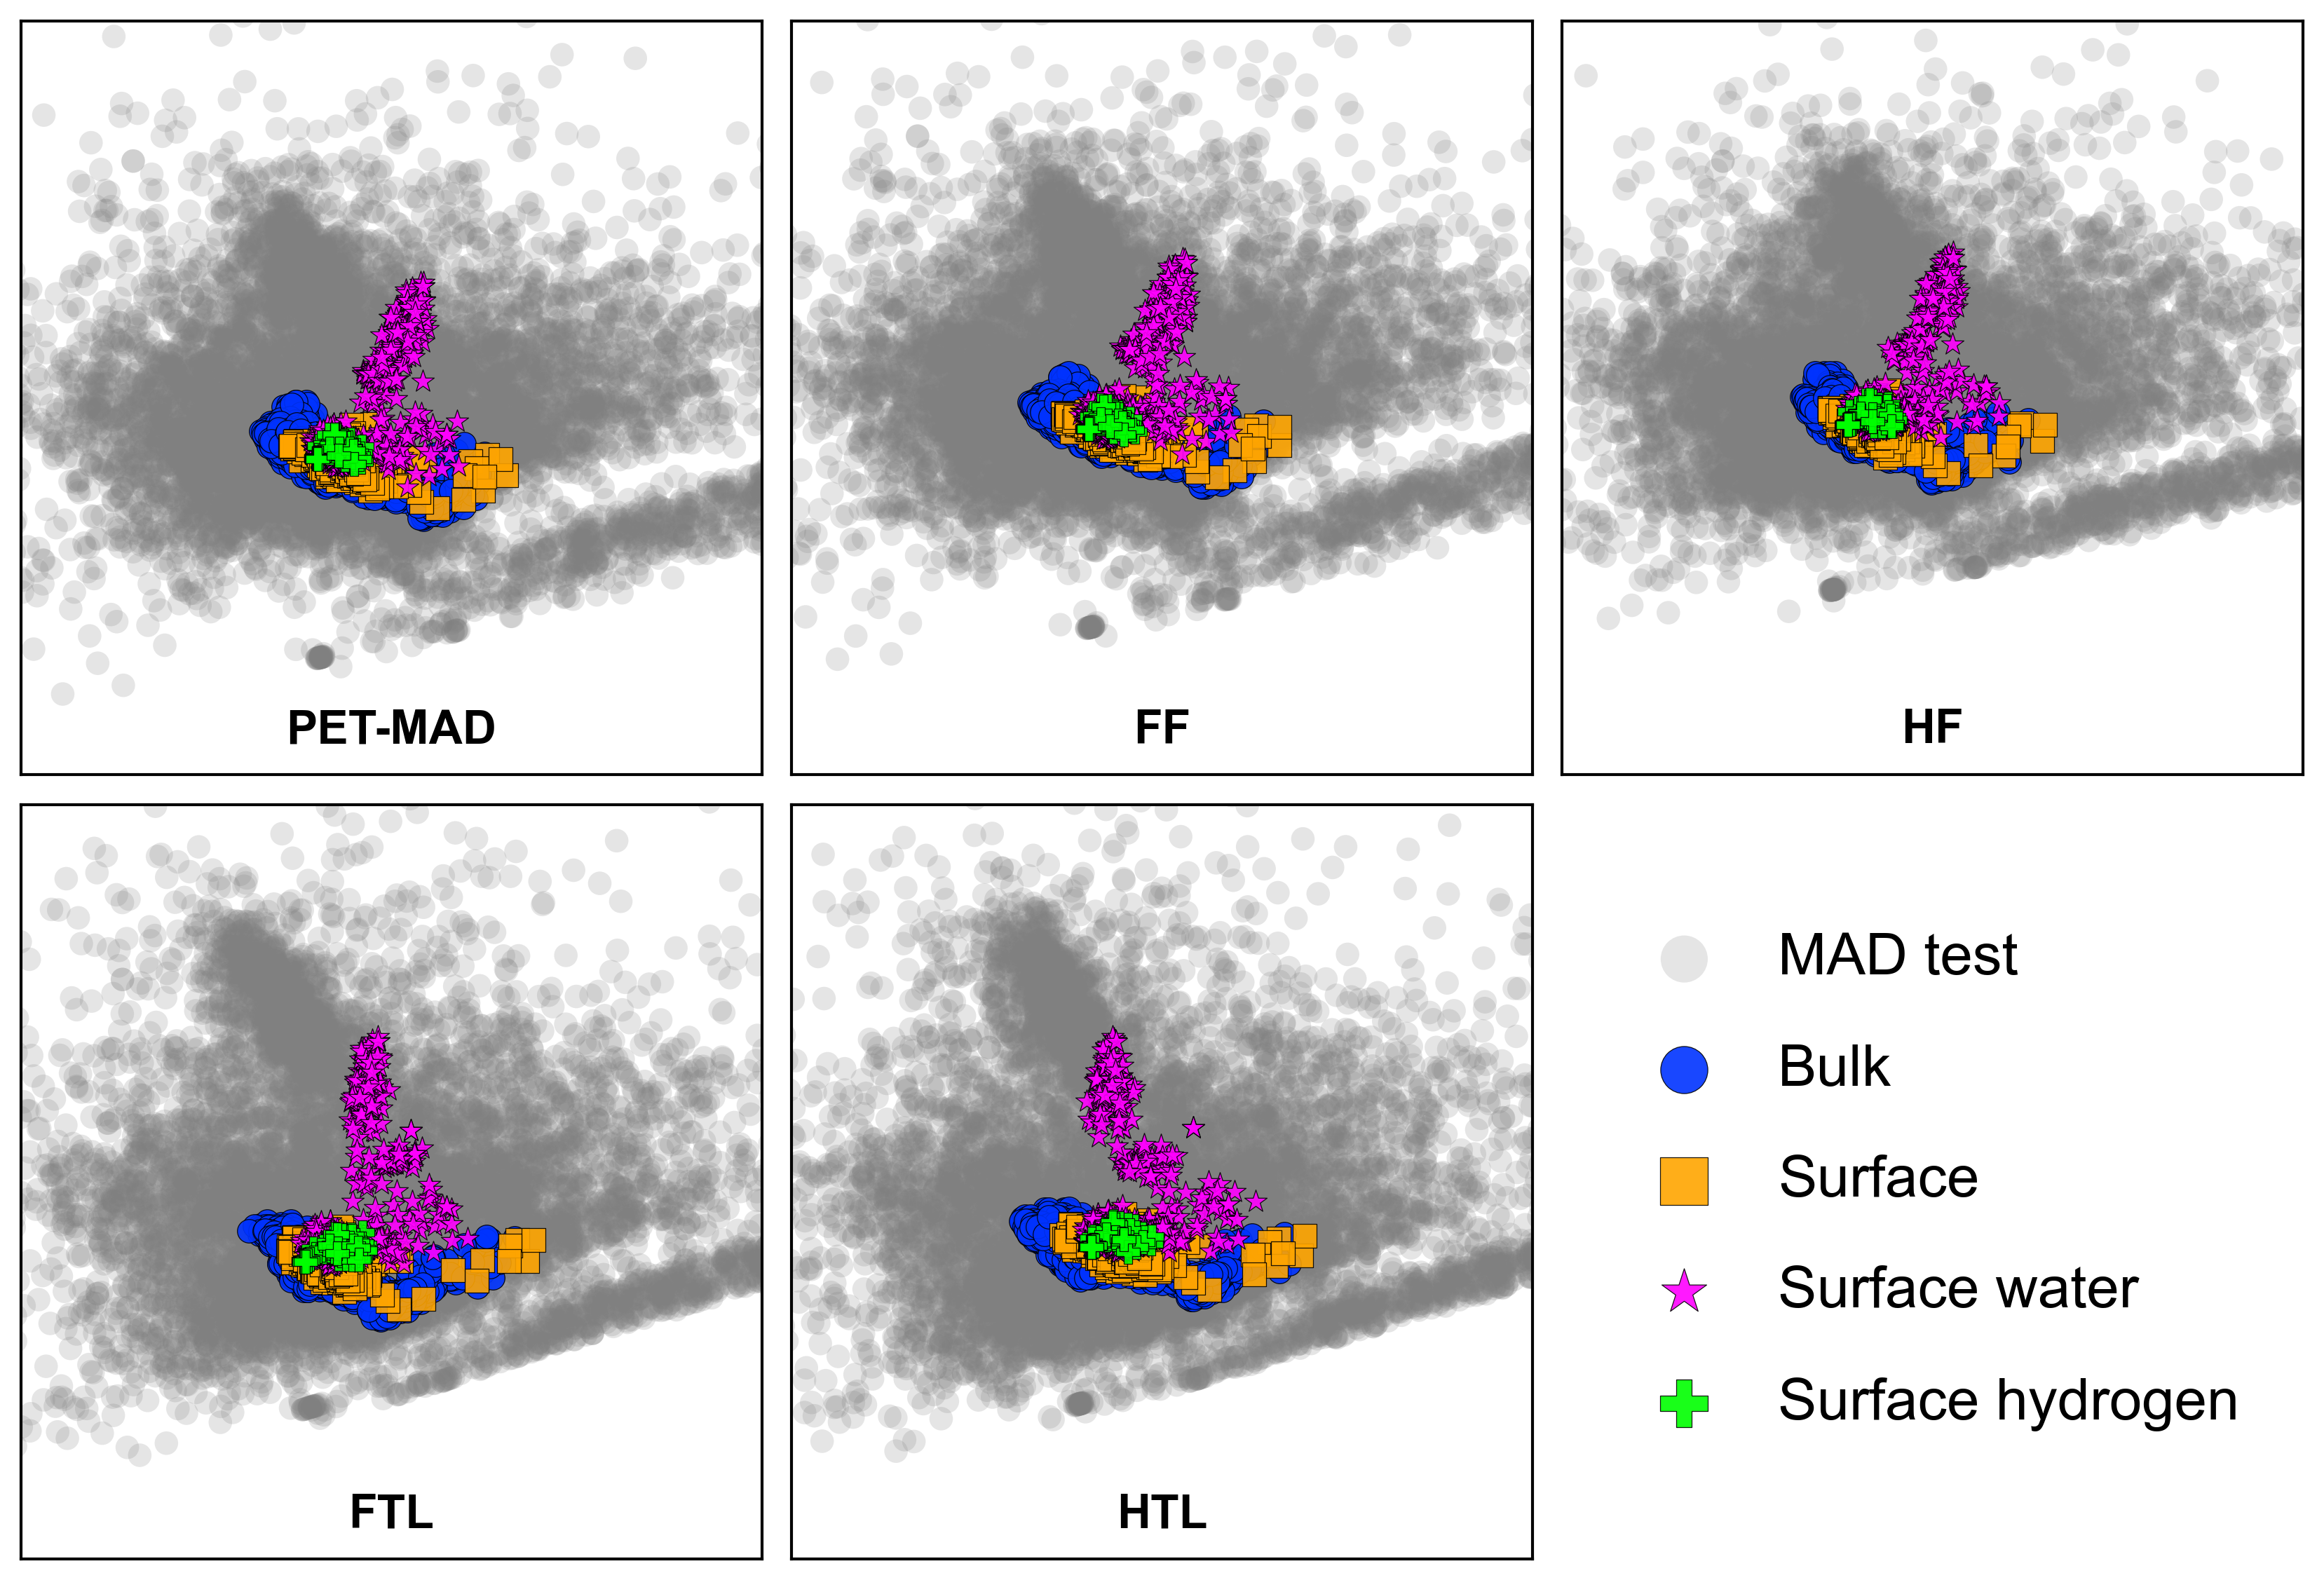

In [7]:
plot_pcovr_lips(datasets, labels_lips, "../results/figures/fine-tuning/pcovr.pdf")